# GBP/USD Daily Directional Bias Prediction
## Random Forest Model with Multi-Timeframe Features

This notebook builds a machine learning model to predict the **daily directional bias** for GBP/USD using:
- Multi-timeframe OHLC data (1D, 4H, 1H, 15M)
- Smart Money Concepts: liquidity sweeps, fair value gaps, structure shifts
- Higher timeframe trend analysis
- Lower timeframe confirmation signals

**Key design principles:**
- Zero lookahead bias — all features use only past data
- Time-series train/test split
- Modular, reusable functions for any forex pair

---
## 1. Setup & Configuration

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    mean_squared_error
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 50)

# ──────────────────────────────────────────────
# CONFIGURATION — change these to use a different pair
# ──────────────────────────────────────────────
PAIR = 'GBPUSD'

# File paths — update these for your environment
PATHS = {
    '1D':  f'/content/gbpusd_1D.csv',
    '4H':  f'/content/gbpusd_4H.csv',
    '1H':  f'/content/gbpusd_1H.csv',
    '15M': f'/content/gbpusd_15M.csv',
}

# Model settings
TRAIN_RATIO = 0.80
RANDOM_STATE = 42

print(f'Pair: {PAIR}')
print('Libraries loaded successfully.')

Pair: GBPUSD
Libraries loaded successfully.


In [11]:
import os
for f in ['gbpusd_1D.csv', 'gbpusd_4H.csv', 'gbpusd_1H.csv', 'gbpusd_15M.csv']:
    path = f'/content/{f}'
    print(f'{path}: {"EXISTS" if os.path.exists(path) else "MISSING"}')

/content/gbpusd_1D.csv: EXISTS
/content/gbpusd_4H.csv: EXISTS
/content/gbpusd_1H.csv: EXISTS
/content/gbpusd_15M.csv: EXISTS


---
## 2. Data Loading & Preprocessing

In [12]:
def load_ohlc(path: str, timeframe: str) -> pd.DataFrame:
    """
    Load an OHLC CSV file, parse timestamps, sort chronologically,
    and add a timeframe label.
    """
    df = pd.read_csv(path, parse_dates=['datetime'])
    df.columns = [c.strip().lower() for c in df.columns]
    df = df.sort_values('datetime').reset_index(drop=True)

    # Add volume column if missing (filled with 0)
    if 'volume' not in df.columns:
        df['volume'] = 0

    # Remove exact-duplicate rows and rows where OHLC are all identical
    # (placeholder/holiday bars)
    df = df.drop_duplicates(subset='datetime')

    df['timeframe'] = timeframe
    return df


# Load all timeframes
data = {}
for tf, path in PATHS.items():
    data[tf] = load_ohlc(path, tf)
    print(f'{tf:>4s}: {len(data[tf]):>7,} rows  |  '
          f'{data[tf]["datetime"].min().date()} → {data[tf]["datetime"].max().date()}')

  1D:   1,630 rows  |  2021-01-01 → 2026-03-31
  4H:   8,387 rows  |  2021-01-01 → 2026-03-31
  1H:  32,343 rows  |  2021-01-01 → 2026-03-31
 15M: 129,151 rows  |  2021-01-01 → 2026-03-31


In [13]:
# Quick sanity check — first few rows of daily data
data['1D'].head(10)

,datetime,open,high,low,close,volume,timeframe
0,2021-01-01,1.344655,1.344655,1.344655,1.344655,0,1D
1,2021-01-03,1.365790,1.368350,1.365580,1.368090,0,1D
2,2021-01-04,1.368210,1.383980,1.334765,1.357130,0,1D
3,2021-01-05,1.357120,1.364110,1.337500,1.362710,0,1D
4,2021-01-06,1.362710,1.367080,1.336560,1.362400,0,1D
5,2021-01-07,1.362410,1.363330,1.334420,1.356900,0,1D
6,2021-01-08,1.356770,1.363580,1.353950,1.356560,0,1D
7,2021-01-10,1.334395,1.356790,1.334350,1.351910,0,1D
8,2021-01-11,1.351910,1.353500,1.331920,1.352360,0,1D
9,2021-01-12,1.352430,1.367000,1.339410,1.366750,0,1D


In [14]:
def remove_placeholder_bars(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove bars where O=H=L=C (weekend/holiday placeholders).
    """
    mask = (df['open'] == df['high']) & (df['high'] == df['low']) & (df['low'] == df['close'])
    removed = mask.sum()
    if removed > 0:
        print(f'  Removed {removed} placeholder bars from {df["timeframe"].iloc[0]}')
    return df[~mask].reset_index(drop=True)


for tf in data:
    data[tf] = remove_placeholder_bars(data[tf])

# Handle any remaining NaN values via forward-fill then backward-fill
for tf in data:
    before = data[tf].isna().sum().sum()
    data[tf] = data[tf].ffill().bfill()
    after = data[tf].isna().sum().sum()
    if before > 0:
        print(f'{tf}: filled {before} NaN values')

print('\nCleaned row counts:')
for tf in data:
    print(f'  {tf}: {len(data[tf]):,}')

  Removed 2 placeholder bars from 1D
  Removed 7 placeholder bars from 4H
  Removed 24 placeholder bars from 1H
  Removed 86 placeholder bars from 15M

Cleaned row counts:
  1D: 1,628
  4H: 8,380
  1H: 32,319
  15M: 129,065


---
## 3. Feature Engineering

All features are computed using **only past data** — no lookahead bias.

### 3A. Higher Timeframe Trend Features (Daily / 4H)

In [15]:
def add_trend_features(df: pd.DataFrame, ma_period: int = 50) -> pd.DataFrame:
    """
    Add trend-related features:
    - Moving average (50-period) and its slope
    - Higher highs / lower lows detection (swing structure)
    - Trend direction encoding
    """
    df = df.copy()

    # 50-period simple moving average
    df['ma50'] = df['close'].rolling(window=ma_period, min_periods=ma_period).mean()

    # MA slope: difference over 5 periods, normalised
    df['ma50_slope'] = (df['ma50'] - df['ma50'].shift(5)) / df['close'] * 100

    # Price position relative to MA
    df['price_vs_ma50'] = (df['close'] - df['ma50']) / df['close'] * 100

    # Swing high/low detection (using 5-bar lookback)
    lookback = 5
    df['swing_high'] = df['high'].rolling(window=lookback, min_periods=lookback).max()
    df['swing_low'] = df['low'].rolling(window=lookback, min_periods=lookback).min()

    # Higher high: current swing high > previous swing high
    df['higher_high'] = (df['swing_high'] > df['swing_high'].shift(lookback)).astype(int)
    df['lower_low'] = (df['swing_low'] < df['swing_low'].shift(lookback)).astype(int)

    # Trend direction: +1 bullish, -1 bearish, 0 neutral
    conditions = [
        (df['close'] > df['ma50']) & (df['ma50_slope'] > 0),   # Bullish
        (df['close'] < df['ma50']) & (df['ma50_slope'] < 0),   # Bearish
    ]
    df['trend_direction'] = np.select(conditions, [1, -1], default=0)

    return df


# Apply to daily and 4H data
data['1D'] = add_trend_features(data['1D'])
data['4H'] = add_trend_features(data['4H'])
print('Trend features added to 1D and 4H.')

Trend features added to 1D and 4H.


### 3B. Liquidity Sweep Features

In [16]:
def add_liquidity_sweep_features(df_daily: pd.DataFrame) -> pd.DataFrame:
    """
    Detect liquidity sweeps of previous day's high and low.
    All features use shift(1) to avoid lookahead bias.
    """
    df = df_daily.copy()

    # Previous day's high and low (shifted to avoid lookahead)
    df['prev_day_high'] = df['high'].shift(1)
    df['prev_day_low'] = df['low'].shift(1)

    # Did today's price sweep previous day's high/low?
    # A sweep means price traded ABOVE previous high or BELOW previous low
    df['swept_prev_day_high'] = (df['high'] > df['prev_day_high']).astype(int)
    df['swept_prev_day_low'] = (df['low'] < df['prev_day_low']).astype(int)

    # Distance from open to previous day levels (normalised as pips-like %)
    df['dist_to_prev_high'] = (df['prev_day_high'] - df['open']) / df['open'] * 10000
    df['dist_to_prev_low'] = (df['open'] - df['prev_day_low']) / df['open'] * 10000

    # Previous day range
    df['prev_day_range'] = (df['prev_day_high'] - df['prev_day_low']) / df['open'] * 10000

    # Was previous day's high swept on the day BEFORE that? (2-day lookback)
    df['swept_prev2_day_high'] = (df['high'].shift(1) > df['high'].shift(2)).astype(int)
    df['swept_prev2_day_low'] = (df['low'].shift(1) < df['low'].shift(2)).astype(int)

    return df


data['1D'] = add_liquidity_sweep_features(data['1D'])
print('Liquidity sweep features added.')

Liquidity sweep features added.


### 3C. Fair Value Gap (FVG) Detection

In [17]:
def detect_fvgs(df: pd.DataFrame) -> pd.DataFrame:
    """
    Detect bullish and bearish Fair Value Gaps (FVGs) and compute features:
    - Number of active FVGs
    - Whether price is inside an FVG
    - FVG respected (wick touches but doesn't close through)
    - FVG disrespected (close through the gap)

    A Bullish FVG: candle[i-2].high < candle[i].low  (gap up)
    A Bearish FVG: candle[i-2].low > candle[i].high  (gap down)
    """
    df = df.copy()

    n = len(df)
    bullish_fvg_count = np.zeros(n)
    bearish_fvg_count = np.zeros(n)
    price_in_bull_fvg = np.zeros(n)
    price_in_bear_fvg = np.zeros(n)
    fvg_respected = np.zeros(n)
    fvg_disrespected = np.zeros(n)

    # Track active FVGs as lists of (top, bottom, type) tuples
    active_fvgs = []

    highs = df['high'].values
    lows = df['low'].values
    closes = df['close'].values
    opens = df['open'].values

    for i in range(2, n):
        # --- Detect new FVGs formed by candle at i-1 (the middle candle) ---
        # Bullish FVG: gap between candle[i-2] high and candle[i] low
        if lows[i] > highs[i - 2]:
            active_fvgs.append({
                'top': lows[i],
                'bottom': highs[i - 2],
                'type': 'bullish',
                'born': i
            })

        # Bearish FVG: gap between candle[i] high and candle[i-2] low
        if highs[i] < lows[i - 2]:
            active_fvgs.append({
                'top': lows[i - 2],
                'bottom': highs[i],
                'type': 'bearish',
                'born': i
            })

        # --- Evaluate active FVGs against current bar ---
        still_active = []
        respected_count = 0
        disrespected_count = 0

        for fvg in active_fvgs:
            # Skip FVGs born this bar (can't interact with yourself)
            if fvg['born'] == i:
                still_active.append(fvg)
                continue

            if fvg['type'] == 'bullish':
                # Price enters FVG zone
                if lows[i] <= fvg['top']:
                    if closes[i] > fvg['bottom']:
                        # Respected: wick dipped in but close stayed above bottom
                        respected_count += 1
                        still_active.append(fvg)
                    else:
                        # Disrespected: closed through the FVG
                        disrespected_count += 1
                        # FVG invalidated — do not keep
                else:
                    still_active.append(fvg)
            else:  # bearish
                if highs[i] >= fvg['bottom']:
                    if closes[i] < fvg['top']:
                        respected_count += 1
                        still_active.append(fvg)
                    else:
                        disrespected_count += 1
                else:
                    still_active.append(fvg)

        # Remove FVGs older than 20 bars to keep the list manageable
        active_fvgs = [f for f in still_active if (i - f['born']) <= 20]

        # Count active FVGs by type
        bull_count = sum(1 for f in active_fvgs if f['type'] == 'bullish')
        bear_count = sum(1 for f in active_fvgs if f['type'] == 'bearish')

        bullish_fvg_count[i] = bull_count
        bearish_fvg_count[i] = bear_count

        # Is current close inside any FVG?
        for fvg in active_fvgs:
            if fvg['bottom'] <= closes[i] <= fvg['top']:
                if fvg['type'] == 'bullish':
                    price_in_bull_fvg[i] = 1
                else:
                    price_in_bear_fvg[i] = 1

        fvg_respected[i] = respected_count
        fvg_disrespected[i] = disrespected_count

    df['bullish_fvg_count'] = bullish_fvg_count
    df['bearish_fvg_count'] = bearish_fvg_count
    df['price_in_bull_fvg'] = price_in_bull_fvg
    df['price_in_bear_fvg'] = price_in_bear_fvg
    df['fvg_respected'] = fvg_respected
    df['fvg_disrespected'] = fvg_disrespected
    df['fvg_net'] = bullish_fvg_count - bearish_fvg_count

    return df


# Detect FVGs on daily, 4H, and 1H timeframes
for tf in ['1D', '4H', '1H']:
    print(f'Detecting FVGs on {tf}...')
    data[tf] = detect_fvgs(data[tf])

print('FVG features added.')

Detecting FVGs on 1D...
Detecting FVGs on 4H...
Detecting FVGs on 1H...
FVG features added.


### 3D. Liquidity Targets (Equal Highs / Equal Lows)

In [18]:
def add_liquidity_targets(df: pd.DataFrame, tolerance_pct: float = 0.0003,
                          lookback: int = 20) -> pd.DataFrame:
    """
    Detect equal highs and equal lows (liquidity pools) and compute
    distance to nearest pools.

    Equal highs/lows: two or more highs/lows within `tolerance_pct` of each
    other within the lookback window.
    """
    df = df.copy()
    n = len(df)

    equal_highs_count = np.zeros(n)
    equal_lows_count = np.zeros(n)
    dist_nearest_eq_high = np.full(n, np.nan)
    dist_nearest_eq_low = np.full(n, np.nan)
    nearest_liq_type = np.zeros(n)  # +1 = high above, -1 = low below

    highs = df['high'].values
    lows = df['low'].values
    closes = df['close'].values

    for i in range(lookback, n):
        window_highs = highs[i - lookback:i]  # Only past data
        window_lows = lows[i - lookback:i]
        current_close = closes[i]

        # Find equal highs: highs within tolerance of each other
        eq_high_levels = []
        for j in range(len(window_highs)):
            for k in range(j + 1, len(window_highs)):
                if abs(window_highs[j] - window_highs[k]) / window_highs[j] < tolerance_pct:
                    level = (window_highs[j] + window_highs[k]) / 2
                    eq_high_levels.append(level)

        # Find equal lows
        eq_low_levels = []
        for j in range(len(window_lows)):
            for k in range(j + 1, len(window_lows)):
                if abs(window_lows[j] - window_lows[k]) / window_lows[j] < tolerance_pct:
                    level = (window_lows[j] + window_lows[k]) / 2
                    eq_low_levels.append(level)

        # Deduplicate nearby levels
        eq_high_levels = list(set([round(x, 5) for x in eq_high_levels]))
        eq_low_levels = list(set([round(x, 5) for x in eq_low_levels]))

        equal_highs_count[i] = len(eq_high_levels)
        equal_lows_count[i] = len(eq_low_levels)

        # Distance to nearest equal high above current price
        above_highs = [h for h in eq_high_levels if h > current_close]
        if above_highs:
            nearest_h = min(above_highs)
            dist_nearest_eq_high[i] = (nearest_h - current_close) / current_close * 10000

        # Distance to nearest equal low below current price
        below_lows = [l for l in eq_low_levels if l < current_close]
        if below_lows:
            nearest_l = max(below_lows)
            dist_nearest_eq_low[i] = (current_close - nearest_l) / current_close * 10000

        # Nearest liquidity type: which pool is closer?
        dh = dist_nearest_eq_high[i] if not np.isnan(dist_nearest_eq_high[i]) else 9999
        dl = dist_nearest_eq_low[i] if not np.isnan(dist_nearest_eq_low[i]) else 9999
        if dh < dl:
            nearest_liq_type[i] = 1   # High-side liquidity is closer
        elif dl < dh:
            nearest_liq_type[i] = -1  # Low-side liquidity is closer

    df['equal_highs_count'] = equal_highs_count
    df['equal_lows_count'] = equal_lows_count
    df['dist_nearest_eq_high'] = dist_nearest_eq_high
    df['dist_nearest_eq_low'] = dist_nearest_eq_low
    df['nearest_liq_type'] = nearest_liq_type

    return df


data['1D'] = add_liquidity_targets(data['1D'])
print('Liquidity target features added.')

Liquidity target features added.


### 3E. Lower Timeframe Confirmation (1H / 15M)

In [19]:
def add_structure_shift_features(df: pd.DataFrame, swing_len: int = 5) -> pd.DataFrame:
    """
    Detect break of structure (BOS) on lower timeframes:
    - Bullish BOS: price breaks above the most recent swing high
    - Bearish BOS: price breaks below the most recent swing low
    Also adds momentum features.
    """
    df = df.copy()

    # Recent swing high/low using rolling window
    df['recent_swing_high'] = df['high'].rolling(window=swing_len, min_periods=swing_len).max().shift(1)
    df['recent_swing_low'] = df['low'].rolling(window=swing_len, min_periods=swing_len).min().shift(1)

    # Break of structure
    df['bullish_bos'] = (df['close'] > df['recent_swing_high']).astype(int)
    df['bearish_bos'] = (df['close'] < df['recent_swing_low']).astype(int)

    # Momentum: recent candle direction over last N candles
    df['candle_direction'] = np.where(df['close'] > df['open'], 1, -1)
    df['momentum_3'] = df['candle_direction'].rolling(3).sum()
    df['momentum_5'] = df['candle_direction'].rolling(5).sum()

    # Body size relative to range (conviction)
    candle_range = df['high'] - df['low']
    candle_body = (df['close'] - df['open']).abs()
    df['body_ratio'] = np.where(candle_range > 0, candle_body / candle_range, 0)

    return df


# Apply to 1H and 15M
for tf in ['1H', '15M']:
    data[tf] = add_structure_shift_features(data[tf])
    print(f'Structure shift features added to {tf}.')

Structure shift features added to 1H.
Structure shift features added to 15M.


### 3F. Aggregate Lower Timeframe Features to Daily Level

We aggregate 4H, 1H, and 15M features into **daily rows** so everything aligns.

In [20]:
def aggregate_to_daily(df: pd.DataFrame, prefix: str, agg_cols: dict) -> pd.DataFrame:
    """
    Aggregate intraday data to daily level.
    Uses the DATE portion of the datetime to group.
    `agg_cols` maps column names to aggregation functions.
    """
    df = df.copy()
    df['date'] = df['datetime'].dt.date

    # Only aggregate columns that exist
    valid_agg = {k: v for k, v in agg_cols.items() if k in df.columns}
    if not valid_agg:
        return pd.DataFrame()

    agg_df = df.groupby('date').agg(valid_agg)
    agg_df.columns = [f'{prefix}_{col}_{func}' for col, func in agg_df.columns]
    agg_df = agg_df.reset_index()
    agg_df['date'] = pd.to_datetime(agg_df['date'])
    return agg_df


# ── Aggregate 4H features ──
agg_4h = aggregate_to_daily(data['4H'], '4h', {
    'trend_direction':    ['last', 'mean'],
    'ma50_slope':         ['last'],
    'price_vs_ma50':      ['last'],
    'higher_high':        ['sum'],
    'lower_low':          ['sum'],
    'bullish_fvg_count':  ['last'],
    'bearish_fvg_count':  ['last'],
    'fvg_respected':      ['sum'],
    'fvg_disrespected':   ['sum'],
})

# ── Aggregate 1H features ──
agg_1h = aggregate_to_daily(data['1H'], '1h', {
    'bullish_bos':       ['sum', 'last'],
    'bearish_bos':       ['sum', 'last'],
    'momentum_3':        ['last', 'mean'],
    'momentum_5':        ['last'],
    'body_ratio':        ['mean'],
    'bullish_fvg_count': ['last'],
    'bearish_fvg_count': ['last'],
    'fvg_respected':     ['sum'],
    'fvg_disrespected':  ['sum'],
})

# ── Aggregate 15M features ──
agg_15m = aggregate_to_daily(data['15M'], '15m', {
    'bullish_bos':       ['sum', 'last'],
    'bearish_bos':       ['sum', 'last'],
    'momentum_3':        ['last'],
    'momentum_5':        ['last'],
    'body_ratio':        ['mean'],
    'candle_direction':  ['sum'],    # Net direction of all 15M candles
})

print(f'Aggregated shapes — 4H: {agg_4h.shape}, 1H: {agg_1h.shape}, 15M: {agg_15m.shape}')

Aggregated shapes — 4H: (1628, 11), 1H: (1628, 13), 15M: (1628, 9)


In [21]:
# ── Merge everything into a single daily dataset ──
daily = data['1D'].copy()
daily['date'] = pd.to_datetime(daily['datetime'].dt.date)

# Merge aggregated intraday features (use previous day's intraday
# data to avoid lookahead: shift the date by 1 day)
for agg_df, name in [(agg_4h, '4H'), (agg_1h, '1H'), (agg_15m, '15M')]:
    if len(agg_df) == 0:
        continue
    # Shift aggregated date forward by 1 day so features are from YESTERDAY
    agg_shifted = agg_df.copy()
    agg_shifted['date'] = agg_shifted['date'] + pd.Timedelta(days=1)
    daily = daily.merge(agg_shifted, on='date', how='left')
    print(f'Merged {name} features. Shape: {daily.shape}')

print(f'\nFinal daily dataset shape: {daily.shape}')
daily.head()

Merged 4H features. Shape: (1628, 47)
Merged 1H features. Shape: (1628, 59)
Merged 15M features. Shape: (1628, 67)

Final daily dataset shape: (1628, 67)


,datetime,open,high,low,close,volume,timeframe,ma50,ma50_slope,price_vs_ma50,swing_high,swing_low,higher_high,lower_low,trend_direction,prev_day_high,prev_day_low,swept_prev_day_high,swept_prev_day_low,dist_to_prev_high,dist_to_prev_low,prev_day_range,swept_prev2_day_high,swept_prev2_day_low,bullish_fvg_count,...,4h_lower_low_sum,4h_bullish_fvg_count_last,4h_bearish_fvg_count_last,4h_fvg_respected_sum,4h_fvg_disrespected_sum,1h_bullish_bos_sum,1h_bullish_bos_last,1h_bearish_bos_sum,1h_bearish_bos_last,1h_momentum_3_last,1h_momentum_3_mean,1h_momentum_5_last,1h_body_ratio_mean,1h_bullish_fvg_count_last,1h_bearish_fvg_count_last,1h_fvg_respected_sum,1h_fvg_disrespected_sum,15m_bullish_bos_sum,15m_bullish_bos_last,15m_bearish_bos_sum,15m_bearish_bos_last,15m_momentum_3_last,15m_momentum_5_last,15m_body_ratio_mean,15m_candle_direction_sum
0,2021-01-03,1.36579,1.36835,1.365580,1.36809,0,1D,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-04,1.36821,1.38398,1.334765,1.35713,0,1D,NaN,NaN,NaN,NaN,NaN,0,0,0,1.36835,1.365580,1,1,1.023235,19.222195,20.245430,0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.670751,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0,5.0,0.559222,4.0
2,2021-01-05,1.35712,1.36411,1.337500,1.36271,0,1D,NaN,NaN,NaN,NaN,NaN,0,0,0,1.38398,1.334765,0,0,197.919123,164.723827,362.642950,1,1,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,0.0,1.0,-0.083333,3.0,0.414994,0.0,4.0,8.0,2.0,10.0,0.0,15.0,0.0,-1.0,-1.0,0.536404,2.0
3,2021-01-06,1.36271,1.36708,1.336560,1.36240,0,1D,NaN,NaN,NaN,NaN,NaN,0,0,0,1.36411,1.337500,1,1,10.273646,184.999009,195.272655,0,0,0.0,...,2.0,0.0,1.0,6.0,0.0,5.0,0.0,1.0,0.0,1.0,-0.083333,-1.0,0.381440,1.0,0.0,8.0,3.0,14.0,0.0,6.0,0.0,3.0,3.0,0.493881,10.0
4,2021-01-07,1.36241,1.36333,1.334420,1.35690,0,1D,NaN,NaN,NaN,1.38398,1.33442,0,0,0,1.36708,1.336560,0,1,34.277494,189.737304,224.014797,1,1,0.0,...,2.0,0.0,1.0,6.0,1.0,2.0,0.0,2.0,0.0,1.0,0.666667,1.0,0.621399,1.0,1.0,9.0,5.0,16.0,0.0,11.0,0.0,3.0,3.0,0.549116,4.0


---
## 4. Label Creation (Target Variable)

**Classification target:** Which level does price hit first — previous day high or previous day low?
- `+1` → hits previous day HIGH first (bullish bias)
- `-1` → hits previous day LOW first (bearish bias)

**Regression target:** Next day return (%)

Both labels are constructed using **next-day data** properly shifted to avoid lookahead.

In [22]:
def create_labels(df_daily: pd.DataFrame, df_15m: pd.DataFrame) -> pd.DataFrame:
    """
    Create target labels:

    Classification: For each day, look at the NEXT day's 15M bars and determine
    whether price hits the current day's high or low first.

    Regression: Next day close-to-close return.
    """
    df = df_daily.copy()

    # ── Regression label: next day return ──
    df['next_day_return'] = df['close'].shift(-1) / df['close'] - 1
    df['next_day_return_pct'] = df['next_day_return'] * 100

    # ── Classification label: which level is hit first ──
    # For day i, we check day i+1's intraday bars against day i's high/low
    df_15m_copy = df_15m.copy()
    df_15m_copy['date'] = df_15m_copy['datetime'].dt.date

    labels = []
    for idx in range(len(df) - 1):
        current_high = df.iloc[idx]['high']
        current_low = df.iloc[idx]['low']
        next_date = df.iloc[idx + 1]['datetime'].date() if hasattr(df.iloc[idx + 1]['datetime'], 'date') else df.iloc[idx + 1]['date'].date()

        # Get next day's 15M bars
        next_day_bars = df_15m_copy[df_15m_copy['date'] == next_date]

        if len(next_day_bars) == 0:
            labels.append(0)  # Unknown
            continue

        hit_label = 0
        for _, bar in next_day_bars.iterrows():
            hit_high = bar['high'] >= current_high
            hit_low = bar['low'] <= current_low

            if hit_high and hit_low:
                # Both hit on same bar — use close direction
                hit_label = 1 if bar['close'] > bar['open'] else -1
                break
            elif hit_high:
                hit_label = 1
                break
            elif hit_low:
                hit_label = -1
                break

        labels.append(hit_label)

    labels.append(0)  # Last row has no next day
    df['target_class'] = labels

    return df


print('Creating labels (this may take a minute)...')
daily = create_labels(daily, data['15M'])

# Show label distribution
print('\nClassification label distribution:')
print(daily['target_class'].value_counts().sort_index())
print(f'\nRegression label stats:')
print(daily['next_day_return_pct'].describe())

Creating labels (this may take a minute)...

Classification label distribution:
target_class
-1    648
 0    353
 1    627
Name: count, dtype: int64

Regression label stats:
count    1627.000000
mean       -0.001048
std         0.479193
min        -3.654985
25%        -0.234347
50%        -0.006706
75%         0.247619
max         3.142744
Name: next_day_return_pct, dtype: float64


---
## 5. Final Dataset Preparation

In [23]:
# ── Select feature columns (exclude raw OHLC, date, labels, metadata) ──
exclude_cols = [
    'datetime', 'date', 'open', 'high', 'low', 'close', 'volume',
    'timeframe', 'ma50', 'swing_high', 'swing_low',
    'prev_day_high', 'prev_day_low',
    'target_class', 'next_day_return', 'next_day_return_pct',
    # Liquidity sweep flags are CURRENT day features — they use today's
    # high/low which is future info for a prediction made at day open.
    # We keep dist_to_prev_high/low (computed from open) and
    # swept_prev2_day (computed from prior days).
    'swept_prev_day_high', 'swept_prev_day_low',
]

feature_cols = [c for c in daily.columns if c not in exclude_cols]
print(f'Number of features: {len(feature_cols)}')
print(f'Features: {feature_cols}')

Number of features: 52
Features: ['ma50_slope', 'price_vs_ma50', 'higher_high', 'lower_low', 'trend_direction', 'dist_to_prev_high', 'dist_to_prev_low', 'prev_day_range', 'swept_prev2_day_high', 'swept_prev2_day_low', 'bullish_fvg_count', 'bearish_fvg_count', 'price_in_bull_fvg', 'price_in_bear_fvg', 'fvg_respected', 'fvg_disrespected', 'fvg_net', 'equal_highs_count', 'equal_lows_count', 'dist_nearest_eq_high', 'dist_nearest_eq_low', 'nearest_liq_type', '4h_trend_direction_last', '4h_trend_direction_mean', '4h_ma50_slope_last', '4h_price_vs_ma50_last', '4h_higher_high_sum', '4h_lower_low_sum', '4h_bullish_fvg_count_last', '4h_bearish_fvg_count_last', '4h_fvg_respected_sum', '4h_fvg_disrespected_sum', '1h_bullish_bos_sum', '1h_bullish_bos_last', '1h_bearish_bos_sum', '1h_bearish_bos_last', '1h_momentum_3_last', '1h_momentum_3_mean', '1h_momentum_5_last', '1h_body_ratio_mean', '1h_bullish_fvg_count_last', '1h_bearish_fvg_count_last', '1h_fvg_respected_sum', '1h_fvg_disrespected_sum', '15

In [24]:
# ── Drop rows with NaN in features or target, and rows with target=0 ──
model_df = daily[feature_cols + ['target_class', 'next_day_return_pct', 'date']].copy()
print(f'Before cleaning: {len(model_df)} rows')

# Fill remaining NaNs in features with 0 (conservative)
model_df[feature_cols] = model_df[feature_cols].fillna(0)

# Remove rows where classification target is 0 (neither level hit)
model_df = model_df[model_df['target_class'] != 0].reset_index(drop=True)
print(f'After removing target=0: {len(model_df)} rows')

# Remove any remaining NaN rows
model_df = model_df.dropna().reset_index(drop=True)
print(f'After dropna: {len(model_df)} rows')

print(f'\nFinal label distribution:')
print(model_df['target_class'].value_counts().sort_index())

Before cleaning: 1628 rows
After removing target=0: 1275 rows
After dropna: 1275 rows

Final label distribution:
target_class
-1    648
 1    627
Name: count, dtype: int64


---
## 6. Train / Test Split (Time-Series)

We use a simple chronological split — no shuffling, no random split.

In [25]:
split_idx = int(len(model_df) * TRAIN_RATIO)

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

X_train = train_df[feature_cols].values
y_train_class = train_df['target_class'].values
y_train_reg = train_df['next_day_return_pct'].values

X_test = test_df[feature_cols].values
y_test_class = test_df['target_class'].values
y_test_reg = test_df['next_day_return_pct'].values

print(f'Train: {len(train_df)} rows ({train_df["date"].min().date()} → {train_df["date"].max().date()})')
print(f'Test:  {len(test_df)} rows  ({test_df["date"].min().date()} → {test_df["date"].max().date()})')
print(f'\nTrain label balance: {dict(zip(*np.unique(y_train_class, return_counts=True)))}')
print(f'Test label balance:  {dict(zip(*np.unique(y_test_class, return_counts=True)))}')

Train: 1020 rows (2021-01-03 → 2025-03-05)
Test:  255 rows  (2025-03-06 → 2026-03-30)

Train label balance: {np.int64(-1): np.int64(519), np.int64(1): np.int64(501)}
Test label balance:  {np.int64(-1): np.int64(129), np.int64(1): np.int64(126)}


---
## 7. Model Training

### 7A. Classification — Random Forest Classifier

In [26]:
# ── Baseline Random Forest Classifier ──
rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train_class)

print('Random Forest Classifier trained.')
print(f'Parameters: {rf_clf.get_params()}')

Random Forest Classifier trained.
Parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 20, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 500, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


### 7B. Regression — Random Forest Regressor

In [27]:
# ── Random Forest Regressor for next-day return ──
rf_reg = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train_reg)

print('Random Forest Regressor trained.')

Random Forest Regressor trained.


---
## 8. Evaluation

### 8A. Classification Evaluation

In [28]:
# ── Classification predictions and metrics ──
y_pred_class = rf_clf.predict(X_test)
y_pred_proba = rf_clf.predict_proba(X_test)

acc = accuracy_score(y_test_class, y_pred_class)
prec = precision_score(y_test_class, y_pred_class, average='weighted')
rec = recall_score(y_test_class, y_pred_class, average='weighted')
f1 = f1_score(y_test_class, y_pred_class, average='weighted')

print('='*50)
print('CLASSIFICATION RESULTS')
print('='*50)
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1 Score:  {f1:.4f}')
print()
print(classification_report(y_test_class, y_pred_class,
                            target_names=['Bearish (-1)', 'Bullish (+1)']))

CLASSIFICATION RESULTS
Accuracy:  0.5961
Precision: 0.5964
Recall:    0.5961
F1 Score:  0.5960

              precision    recall  f1-score   support

Bearish (-1)       0.60      0.58      0.59       129
Bullish (+1)       0.59      0.61      0.60       126

    accuracy                           0.60       255
   macro avg       0.60      0.60      0.60       255
weighted avg       0.60      0.60      0.60       255



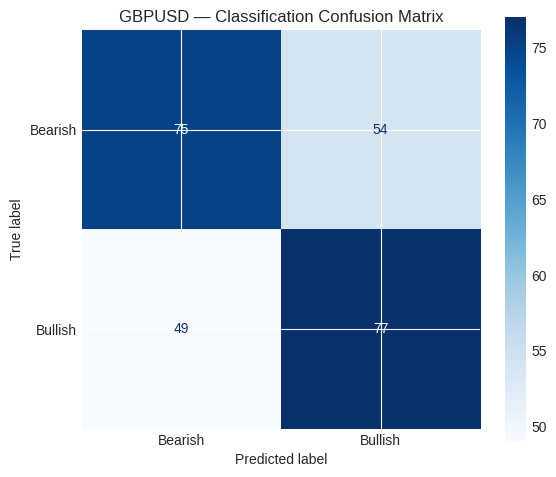

In [29]:
# ── Confusion Matrix ──
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_class, y_pred_class)
disp = ConfusionMatrixDisplay(cm, display_labels=['Bearish', 'Bullish'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'{PAIR} — Classification Confusion Matrix')
plt.tight_layout()
plt.show()

### 8B. Regression Evaluation

In [30]:
# ── Regression predictions and metrics ──
y_pred_reg = rf_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

# Directional accuracy: did the model predict the correct sign?
dir_acc = np.mean(np.sign(y_pred_reg) == np.sign(y_test_reg))

print('='*50)
print('REGRESSION RESULTS')
print('='*50)
print(f'RMSE:                {rmse:.4f}%')
print(f'Directional Accuracy: {dir_acc:.4f}')

REGRESSION RESULTS
RMSE:                0.4641%
Directional Accuracy: 0.5216


---
## 9. Visualisation

### 9A. Feature Importance

CLASSIFIER Feature Importance:


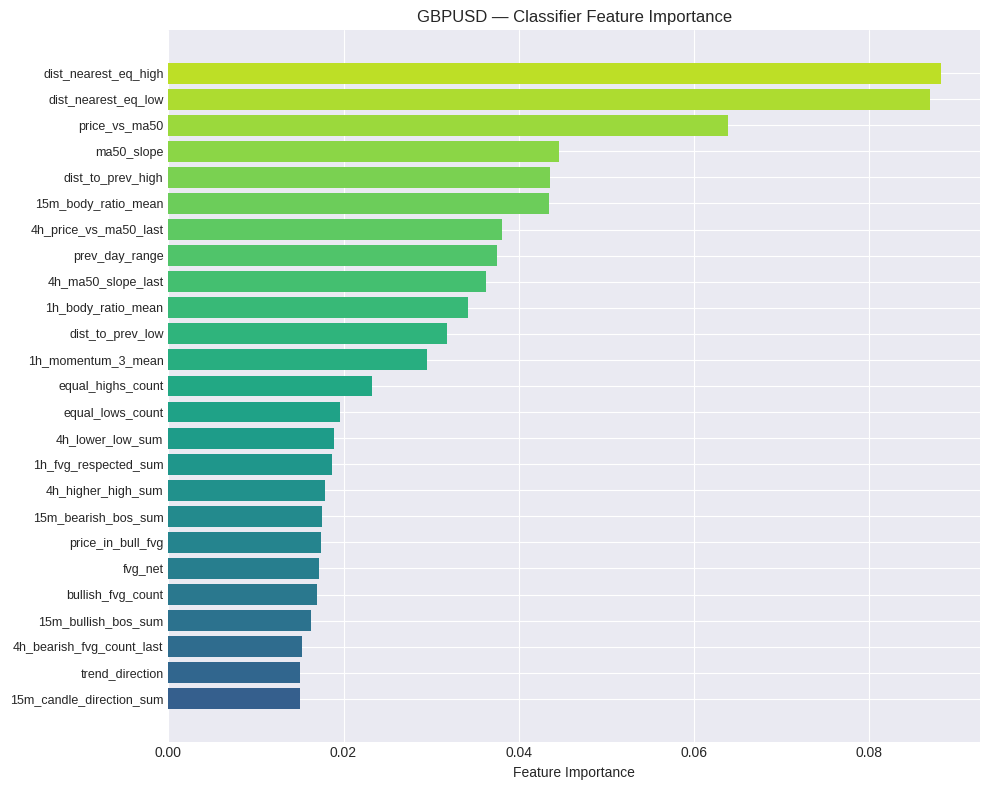


REGRESSOR Feature Importance:


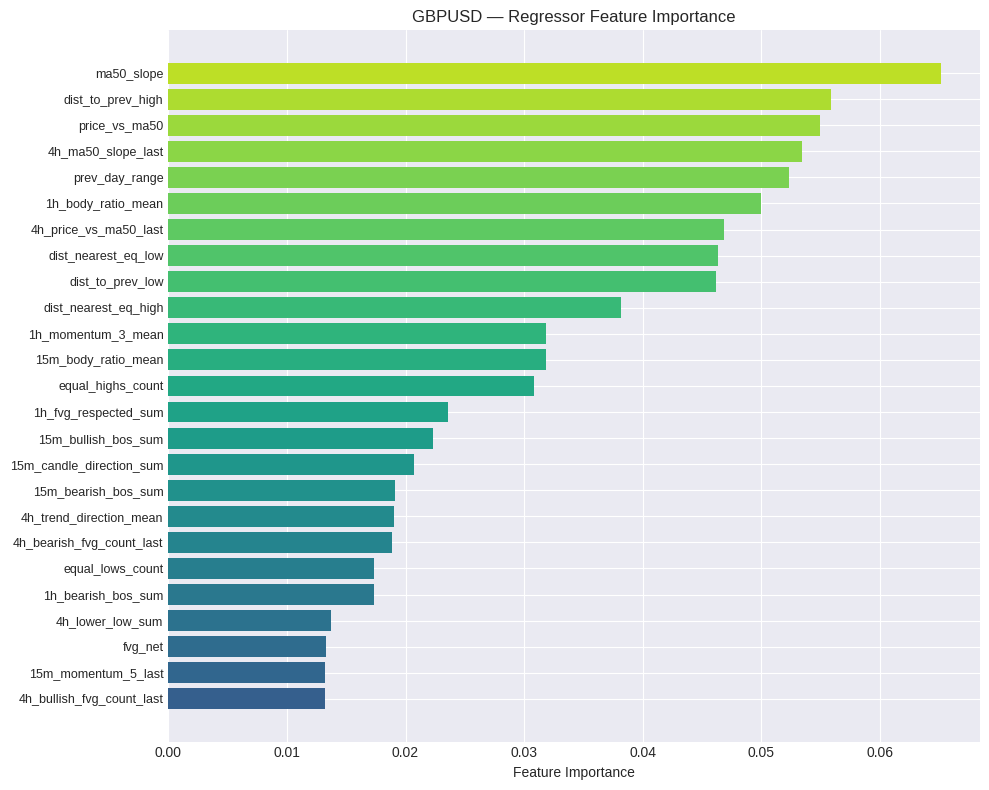

In [31]:
def plot_feature_importance(model, feature_names, title, top_n=25):
    """
    Plot top N most important features from a Random Forest model.
    """
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = [feature_names[i] for i in indices]
    top_importances = importances[indices]

    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
    ax.barh(range(len(top_features)), top_importances[::-1], color=colors)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features[::-1], fontsize=9)
    ax.set_xlabel('Feature Importance')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return list(zip(top_features, top_importances))


print('CLASSIFIER Feature Importance:')
clf_imp = plot_feature_importance(rf_clf, feature_cols,
                                  f'{PAIR} — Classifier Feature Importance')

print('\nREGRESSOR Feature Importance:')
reg_imp = plot_feature_importance(rf_reg, feature_cols,
                                  f'{PAIR} — Regressor Feature Importance')

### 9B. Predictions vs Actual

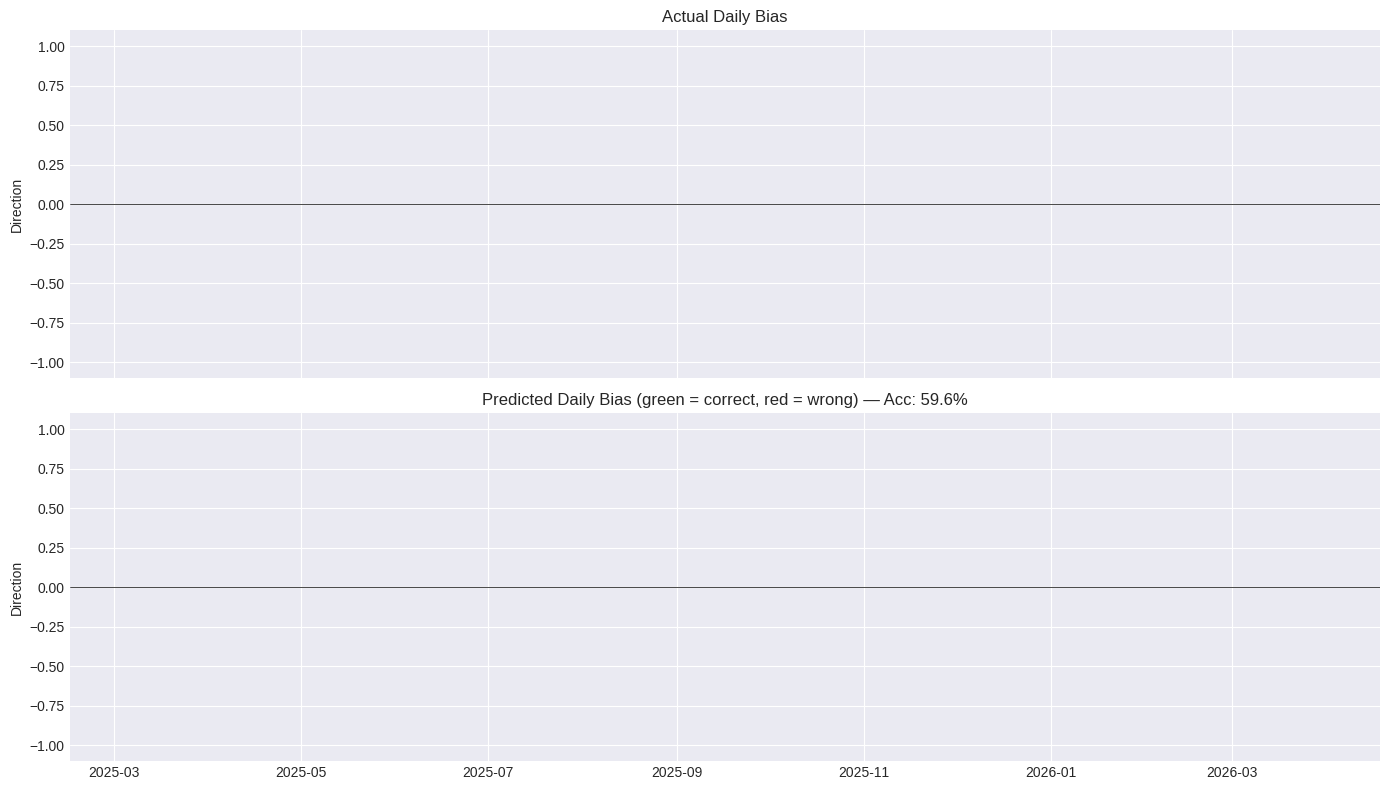

In [32]:
# ── Classification: Predictions vs Actual over time ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

test_dates = test_df['date'].values

# Actual labels
axes[0].bar(test_dates, y_test_class, color=np.where(y_test_class == 1, 'green', 'red'),
            alpha=0.6, width=1)
axes[0].set_ylabel('Direction')
axes[0].set_title('Actual Daily Bias')
axes[0].axhline(0, color='black', linewidth=0.5)

# Predicted labels
colors = np.where(y_pred_class == y_test_class, 'green', 'red')
axes[1].bar(test_dates, y_pred_class, color=colors, alpha=0.6, width=1)
axes[1].set_ylabel('Direction')
axes[1].set_title(f'Predicted Daily Bias (green = correct, red = wrong) — Acc: {acc:.1%}')
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

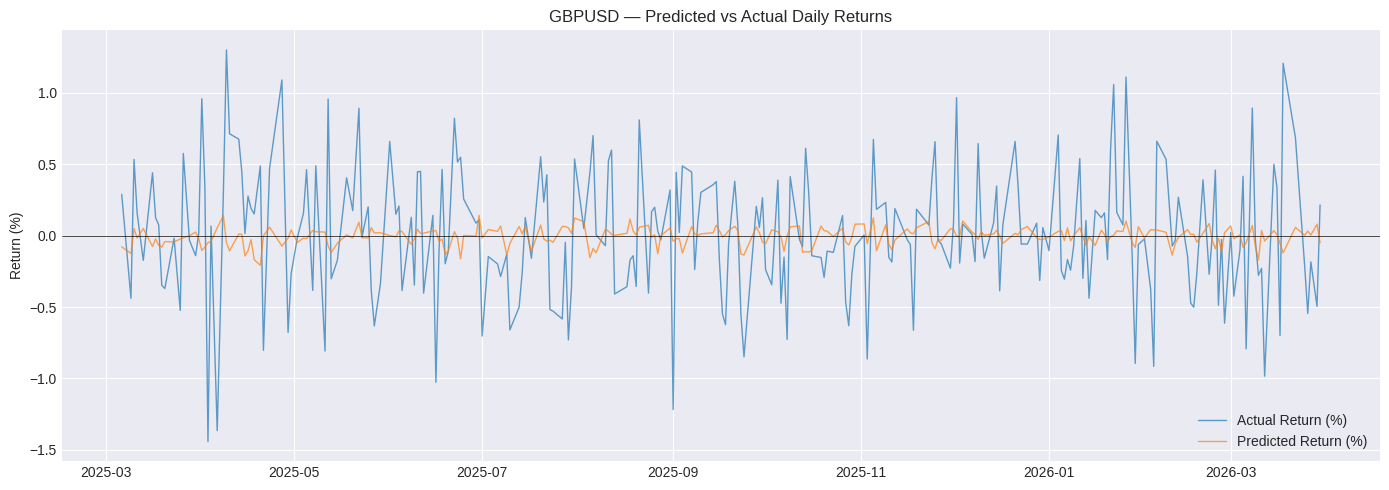

In [33]:
# ── Regression: Predicted vs Actual returns ──
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test_dates, y_test_reg, label='Actual Return (%)', alpha=0.7, linewidth=1)
ax.plot(test_dates, y_pred_reg, label='Predicted Return (%)', alpha=0.7, linewidth=1)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Return (%)')
ax.set_title(f'{PAIR} — Predicted vs Actual Daily Returns')
ax.legend()
plt.tight_layout()
plt.show()

### 9C. Equity Curve Simulation

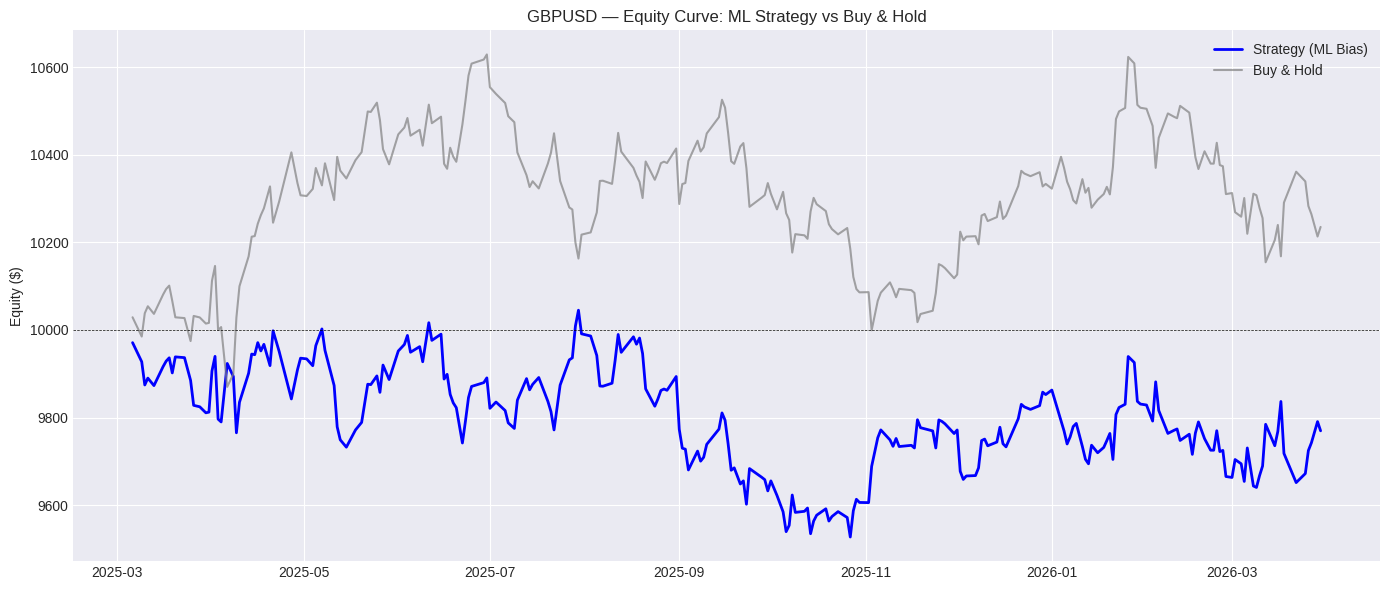

Strategy Total Return: -2.30%
Annualised Sharpe Ratio: -0.28
Max Drawdown: -5.16%


In [34]:
def simulate_equity_curve(predictions, actual_returns, initial_capital=10000):
    """
    Simple equity curve: go long if prediction is +1, short if -1.
    Uses the classification predictions and actual next-day returns.
    No leverage, no transaction costs.
    """
    # Convert classification predictions to position: +1 or -1
    positions = predictions.copy().astype(float)

    # Strategy return = position * actual return
    strategy_returns = positions * actual_returns / 100  # convert pct to decimal

    # Cumulative equity
    equity = initial_capital * (1 + strategy_returns).cumprod()
    buy_hold = initial_capital * (1 + actual_returns / 100).cumprod()

    return equity, buy_hold, strategy_returns


equity, buy_hold, strat_returns = simulate_equity_curve(y_pred_class, y_test_reg)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates, equity, label='Strategy (ML Bias)', linewidth=2, color='blue')
ax.plot(test_dates, buy_hold, label='Buy & Hold', linewidth=1.5, color='gray', alpha=0.7)
ax.axhline(10000, color='black', linewidth=0.5, linestyle='--')
ax.set_ylabel('Equity ($)')
ax.set_title(f'{PAIR} — Equity Curve: ML Strategy vs Buy & Hold')
ax.legend()
plt.tight_layout()
plt.show()

# Key metrics
total_return = (equity[-1] / 10000 - 1) * 100
sharpe = np.mean(strat_returns) / (np.std(strat_returns) + 1e-8) * np.sqrt(252)
max_dd = ((equity / np.maximum.accumulate(equity)) - 1).min() * 100

print(f'Strategy Total Return: {total_return:.2f}%')
print(f'Annualised Sharpe Ratio: {sharpe:.2f}')
print(f'Max Drawdown: {max_dd:.2f}%')

---
## 10. Hyperparameter Tuning (Bonus)

In [35]:
# ── RandomizedSearchCV with TimeSeriesSplit ──
param_distributions = {
    'n_estimators': [200, 300, 500, 700, 1000],
    'max_depth': [5, 7, 10, 15, 20, None],
    'min_samples_leaf': [5, 10, 20, 30],
    'min_samples_split': [10, 20, 30, 50],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'class_weight': ['balanced', 'balanced_subsample', None],
}

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions,
    n_iter=30,
    cv=tscv,
    scoring='f1_weighted',
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=-1
)

print('Running hyperparameter search (this may take a few minutes)...')
search.fit(X_train, y_train_class)

print(f'\nBest params: {search.best_params_}')
print(f'Best CV F1:  {search.best_score_:.4f}')

Running hyperparameter search (this may take a few minutes)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params: {'n_estimators': 700, 'min_samples_split': 30, 'min_samples_leaf': 10, 'max_features': 0.3, 'max_depth': 7, 'class_weight': 'balanced_subsample'}
Best CV F1:  0.6155


TUNED MODEL RESULTS
Accuracy:  0.6157  (baseline: 0.5961)
F1 Score:  0.6150  (baseline: 0.5960)

              precision    recall  f1-score   support

Bearish (-1)       0.63      0.57      0.60       129
Bullish (+1)       0.60      0.66      0.63       126

    accuracy                           0.62       255
   macro avg       0.62      0.62      0.62       255
weighted avg       0.62      0.62      0.62       255



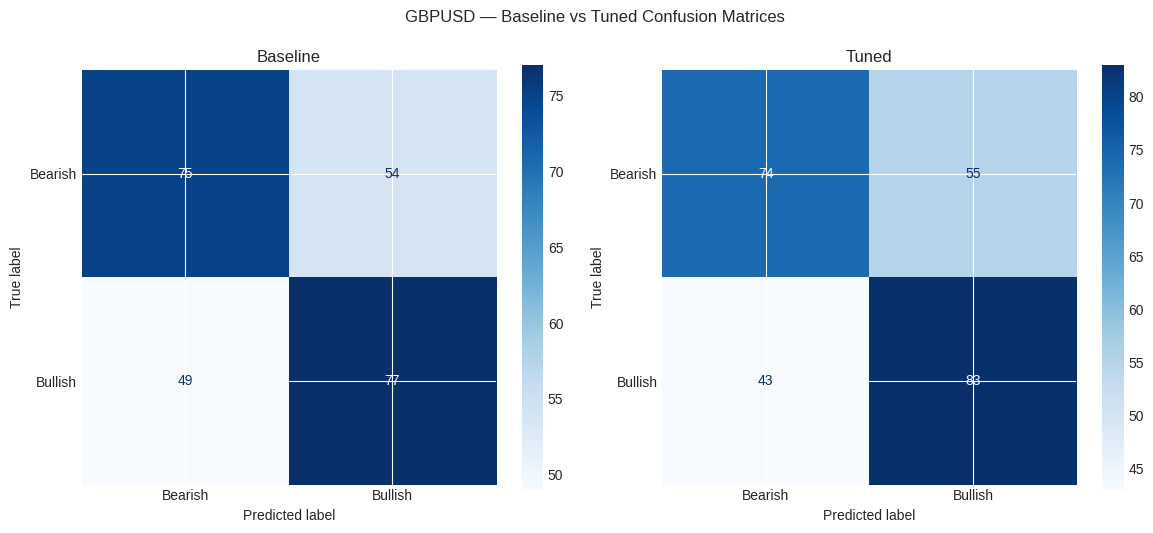

In [36]:
# ── Evaluate the tuned model ──
best_clf = search.best_estimator_
y_pred_tuned = best_clf.predict(X_test)

acc_tuned = accuracy_score(y_test_class, y_pred_tuned)
f1_tuned = f1_score(y_test_class, y_pred_tuned, average='weighted')

print('='*50)
print('TUNED MODEL RESULTS')
print('='*50)
print(f'Accuracy:  {acc_tuned:.4f}  (baseline: {acc:.4f})')
print(f'F1 Score:  {f1_tuned:.4f}  (baseline: {f1:.4f})')
print()
print(classification_report(y_test_class, y_pred_tuned,
                            target_names=['Bearish (-1)', 'Bullish (+1)']))

# Confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in [
    (axes[0], y_pred_class, 'Baseline'),
    (axes[1], y_pred_tuned, 'Tuned'),
]:
    cm = confusion_matrix(y_test_class, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Bearish', 'Bullish'])
    disp.plot(ax=ax, cmap='Blues')
    ax.set_title(title)
plt.suptitle(f'{PAIR} — Baseline vs Tuned Confusion Matrices', y=1.02)
plt.tight_layout()
plt.show()

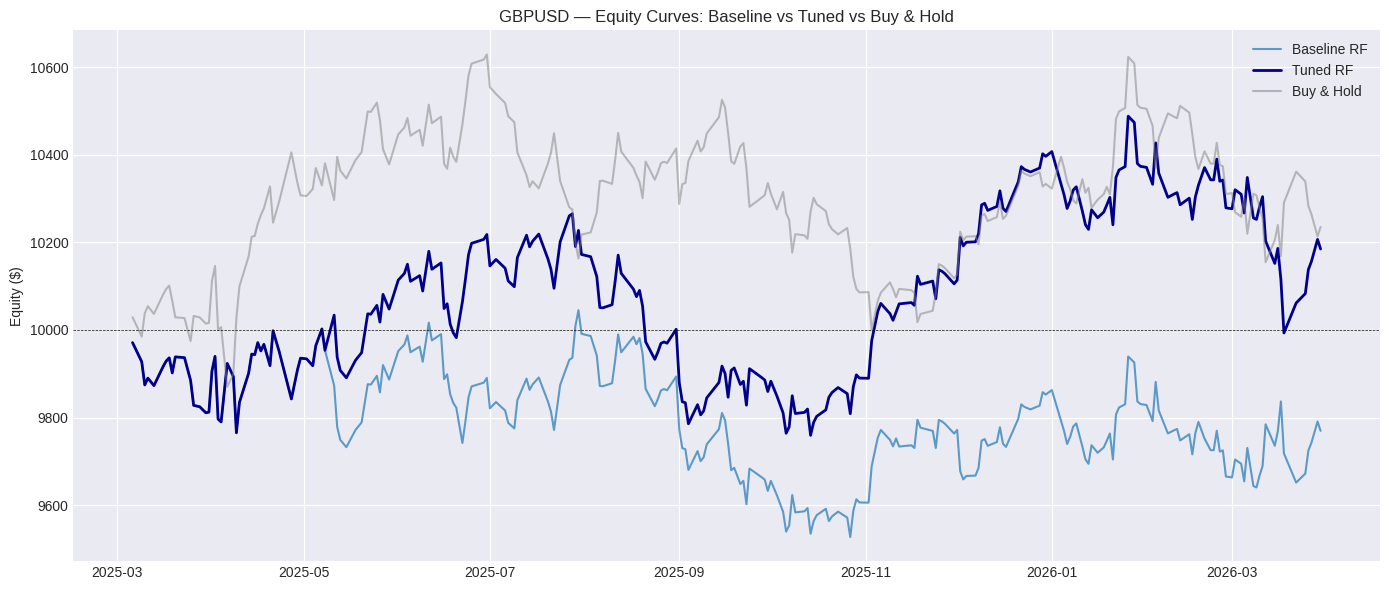

In [37]:
# ── Tuned model equity curve ──
equity_tuned, _, strat_returns_tuned = simulate_equity_curve(y_pred_tuned, y_test_reg)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates, equity, label='Baseline RF', linewidth=1.5, alpha=0.7)
ax.plot(test_dates, equity_tuned, label='Tuned RF', linewidth=2, color='darkblue')
ax.plot(test_dates, buy_hold, label='Buy & Hold', linewidth=1.5, color='gray', alpha=0.5)
ax.axhline(10000, color='black', linewidth=0.5, linestyle='--')
ax.set_ylabel('Equity ($)')
ax.set_title(f'{PAIR} — Equity Curves: Baseline vs Tuned vs Buy & Hold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 11. Summary & Next Steps

### What this notebook does:
1. Loads multi-timeframe GBP/USD data (1D, 4H, 1H, 15M)
2. Engineers features from ICT/Smart Money concepts:
   - Higher timeframe trend direction, MA slopes, swing structure
   - Liquidity sweeps of previous day levels
   - Fair Value Gap detection and interaction features
   - Equal highs/lows as liquidity targets
   - Lower timeframe structure shifts and momentum
3. Creates both classification and regression targets
4. Trains Random Forest models with time-series proper splits
5. Evaluates with standard ML metrics + equity curve

### To use with a different pair:
1. Update the `PAIR` variable and `PATHS` dictionary in cell 1
2. Re-run the entire notebook

### Potential improvements:
- Add session-based features (London open, NY open)
- Add order block detection
- Ensemble with XGBoost / LightGBM
- Walk-forward validation instead of a single split
- Add spread/slippage to equity curve simulation
- Feature selection (remove low-importance features)
- Add ATR-based position sizing